# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

Optei por seguir os passos como orientado no material acima:
Exploração dos dados

In [36]:
import pandas as pd

In [37]:
clientes = pd.read_csv("Mall_Customers.csv", delimiter=',')

In [38]:
clientes.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [39]:
clientes.dtypes

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [40]:
clientes["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [43]:
clientes['Gender'] = clientes['Gender'].map({'Male': 0, 'Female': 1})

In [44]:
clientes.dtypes

CustomerID                int64
Gender                    int64
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [45]:
clientes.head(50)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40
5,6,1,22,17,76
6,7,1,35,18,6
7,8,1,23,18,94
8,9,0,64,19,3
9,10,1,30,19,72


In [56]:
clientes[clientes['Age'] <= 0]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [57]:
clientes[clientes['Annual Income (k$)'] < 0]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [58]:
clientes[
    (clientes['Spending Score (1-100)'] < 0) |
    (clientes['Spending Score (1-100)'] > 100)
]

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [46]:
clientes.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [48]:
print(clientes.info())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB
None


In [50]:
(clientes.duplicated().sum())

np.int64(0)

In [ ]:
#Não tem dados nulos, duplicados ou faltantes. A variável gênero foi convrtida para numérica para poder ser utilizada.

In [55]:
clientes.drop(columns=['Gender','CustomerID']).describe(include='all')

,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [54]:
clientes['Gender'].value_counts(normalize=True, dropna=False) * 100

Gender
1    56.0
0    44.0
Name: proportion, dtype: float64

A maior parte dos clientes são mulheres,representando 56% dos dados. Já a média de idade é aproximadamente 39 anos, a média da renda anual 60.56 e o score 50. É importante detacar que os dados paresentam uma dispersão considerável de quase a metade da média.

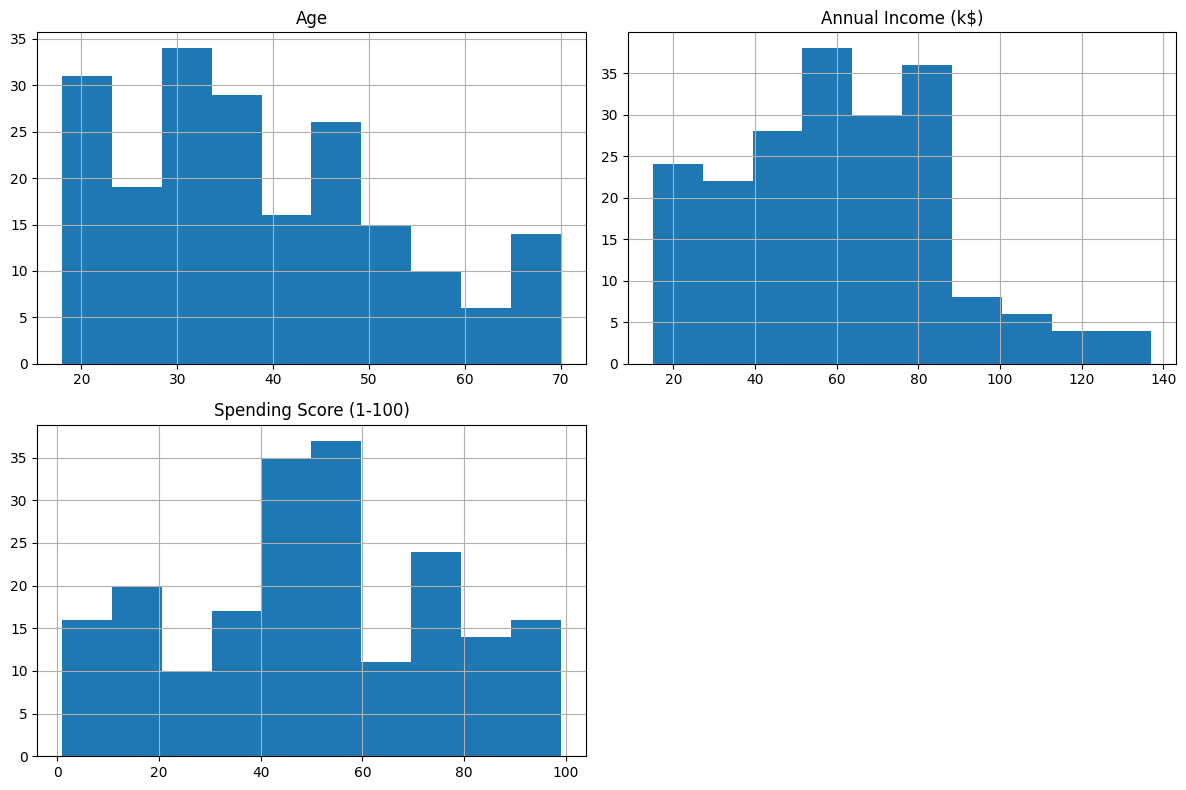

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

clientes.drop(columns=['Gender','CustomerID']).hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [ ]:
Os gráficos mostram visualmente o que foi observado anteriormente pelo valor da média.

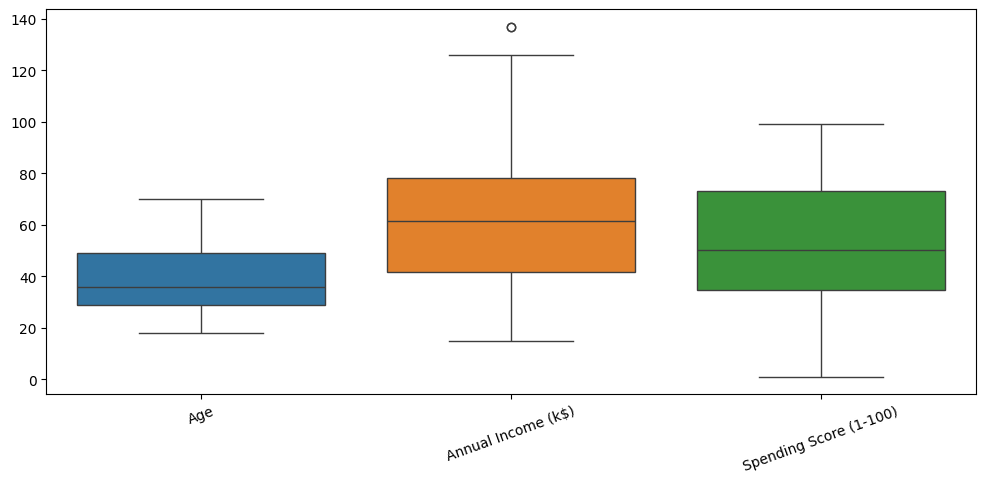

In [61]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=clientes[['Age', 
                           'Annual Income (k$)', 
                           'Spending Score (1-100)']])

plt.xticks(rotation=20)
plt.show()

Como o dp estava muito alto fui observar através do boxplot a presença de outlier.Entretanto, apesar dos dados estarem bem dispersos só identifiquei um outlier em renda anual que foi removido abaixo.

In [62]:
Q1 = clientes['Annual Income (k$)'].quantile(0.25)
Q3 = clientes['Annual Income (k$)'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(limite_inferior)
print(limite_superior)

-13.25
132.75


In [63]:
clientes = clientes[
    (clientes['Annual Income (k$)'] >= limite_inferior) &
    (clientes['Annual Income (k$)'] <= limite_superior)
]

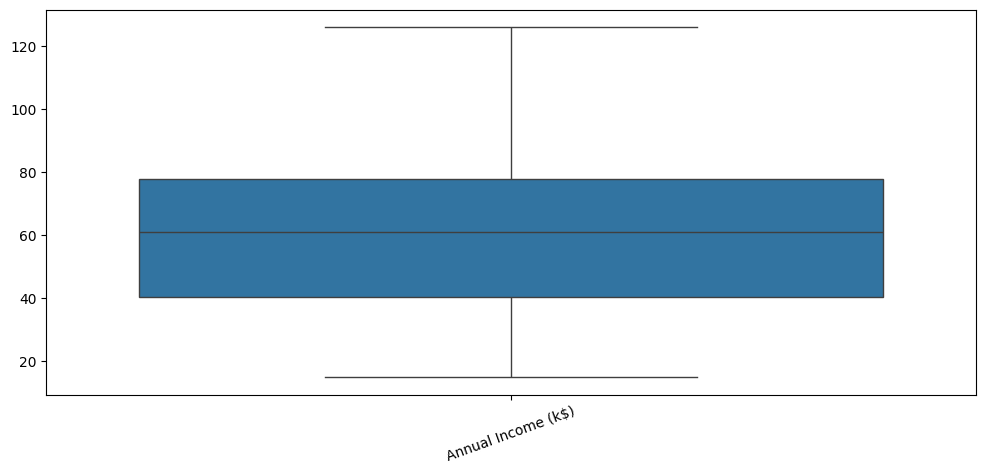

In [64]:
plt.figure(figsize=(12, 5))

sns.boxplot(data=clientes[['Annual Income (k$)']])

plt.xticks(rotation=20)
plt.show()

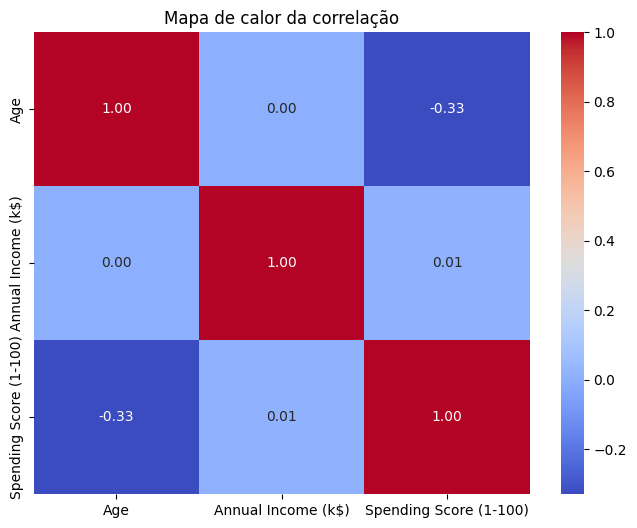

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

correlacao = clientes.drop(columns=['Gender','CustomerID']).corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacao,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Mapa de calor da correlação')
plt.show()

A única correlação média identificada foi entre score e idade de 33% e negativa. Após a análise as variáveis selecionadas foram normalizadas para ficarem na mesma escala e o modelo não atribuir "mais peso" a uma variável como a renda anual só pq ela é bem maior. Não vi necessidade de criar novas variáveis para evitar adicionar informações repstitivas e desnecessárias já que são poucas e bem objetivas.

In [67]:
from sklearn.preprocessing import StandardScaler

X = clientes[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [78]:
X_scaled[:5]  #Para ver se funcionou

array([[-1.42541358, -1.77917141, -0.43598941],
       [-1.2823665 , -1.77917141,  1.19941337],
       [-1.35389004, -1.73944701, -1.72094874],
       [-1.13931942, -1.73944701,  1.04366072],
       [-0.5671311 , -1.69972262, -0.39705125]])

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

In [82]:
from sklearn.cluster import KMeans
kmeans_perfil_compra= KMeans(
    n_clusters = 3,
    n_init = 10,
    random_state = 42)
kmeans_perfil_compra.fit(X_scaled)
centroides = kmeans_perfil_compra.cluster_centers_
centroides #aqui está padronzado, não dá para ver bem então vou remover
    

array([[-0.4277519 ,  0.99338768,  1.21838324],
       [ 0.8208726 ,  0.0270472 , -0.65623339],
       [-0.98605469, -0.65616905,  0.24573745]])

In [85]:
centroides_padronizados = kmeans_perfil_compra.cluster_centers_
centroides_originais = scaler.inverse_transform(centroides_padronizados)
centroides_originais

array([[32.94871795, 84.79487179, 81.48717949],
       [50.40625   , 60.46875   , 33.34375   ],
       [25.14285714, 43.26984127, 56.50793651]])

A separação em 3 grupos rendeu como "média" para distancia, centróide dos grupos(Definindo 3 clusteres, grupos, perfis de cliente):

        Idade       R Anual         Score
G1        32          84.7           81.4
G2        50          60.4           33.3
G3        25          43.2           56.5

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

In [87]:
clientes['Cluster'] = kmeans_perfil_compra.labels_ #Adiciona aos dados uma coluna com o grupo.

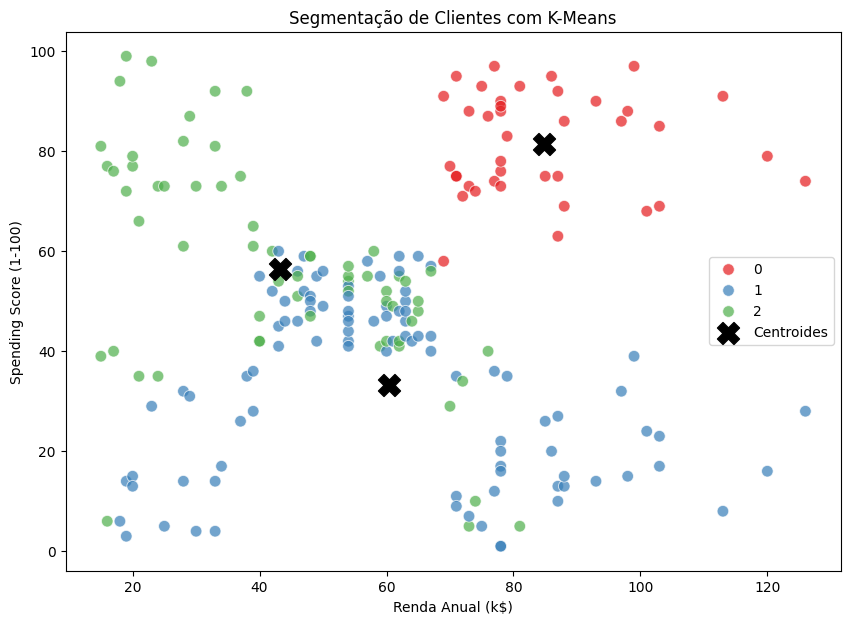

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Centroides na escala original
centroides_originais = scaler.inverse_transform(
    kmeans_perfil_compra.cluster_centers_
)

# Gráfico
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=clientes,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=70,
    alpha=0.7
)

# Adicionando os centroides
plt.scatter(
    centroides_originais[:, 1],
    centroides_originais[:, 2],
    c='black',
    marker='X',
    s=250,
    label='Centroides'
)

plt.title('Segmentação de Clientes com K-Means')
plt.xlabel('Renda Anual (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()

plt.show()

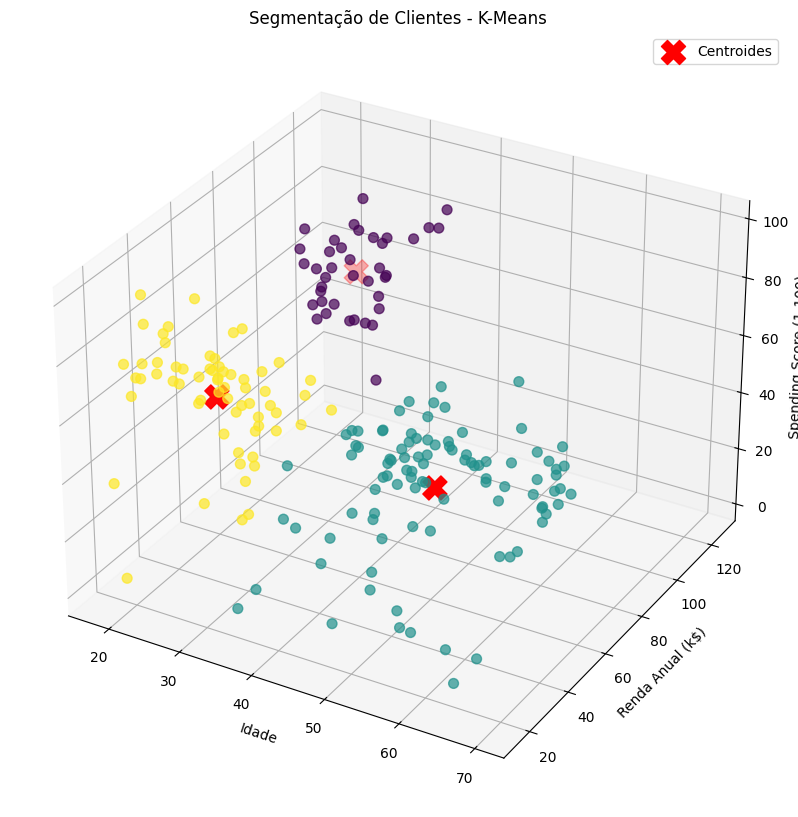

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Centroides voltando para a escala original
centroides_originais = scaler.inverse_transform(
    kmeans_perfil_compra.cluster_centers_
)

# Criando o gráfico 3D
fig = plt.figure(figsize=(10, 15))
ax = fig.add_subplot(111, projection='3d')

# Clientes
scatter = ax.scatter(
    clientes['Age'],
    clientes['Annual Income (k$)'],
    clientes['Spending Score (1-100)'],
    c=clientes['Cluster'],
    cmap='viridis',
    s=50,
    alpha=0.7
)

# Centroides
ax.scatter(
    centroides_originais[:, 0],
    centroides_originais[:, 1],
    centroides_originais[:, 2],
    c='red',
    marker='X',
    s=300,
    label='Centroides'
)

# Nomes dos eixos
ax.set_xlabel('Idade')
ax.set_ylabel('Renda Anual (k$)')
ax.set_zlabel('Spending Score (1-100)')

ax.set_title('Segmentação de Clientes - K-Means')

ax.legend()

plt.show()

Esse é um outro grafico onde adicionando a idade é possível ver melhor o perfil dos grupos mostrados numericamente acima e uma boa distância entre eles.

G1 — Clientes de alto valor: idade média de 32 anos, renda anual elevada (84,7 k$) e o maior Spending Score (81,4).São clientes relativamente jovens, com maior poder aquisitivo e alta propensão ao consumo por isso podem trazer bastante dinheiro para a empresa. Estratégias para uso do perfil criado: Ofertas de produtos exclusivos e Programas de fidelidadec pontos e cashback.
G2 — Clientes de baixo engajamento: maior idade média (50 anos) e renda intermediária de 60,4 k$, mas apresenta o menor Spending Score, de apenas 33,3 eles possuem capacidade financeira razoável, mas que não apresentam alto nível de consumo. Estratégias para uso do perfil criado: estimular o consumo do que eles já compram além de crir ofertas personalizadas e campanhas de reativação.
G3 — Clientes jovens de consumo moderado: menor idade média (25 anos) e também a menor renda média (43,2 k$). Apesar disso, possui um Spending Score de 56,5, superior ao G2,um público jovem, com menor poder aquisitivo. Estratégias para uso do perfil criado: fidelizar para aproveitar esse cliente a longo prazo fazendo promoções e descontos, campanhas em redes sociais e ofertas personalizadas com preços acessíveis.



Alexandre William Camargo • ago 16 08:37
Olá Regina, espero que esteja tudo bem com você!

A tarefa está bem desenvolvida e apresentou um projeto bem estruturado, com uma sequência lógica das etapas de exploração, tratamento dos dados, aplicação do K-Means e interpretação dos resultados.

A análise exploratória foi conduzida de forma adequada, verificando tipos de dados, valores ausentes, duplicados, inconsistências e distribuições das variáveis. Também foi positivo validar a existência de valores inválidos para idade, renda e score antes de prosseguir com a modelagem. A conversão da variável de gênero para formato numérico demonstra preocupação com a preparação dos dados para possíveis análises futuras.

Outro destaque foi a utilização de histogramas, boxplots e matriz de correlação para compreender o comportamento das variáveis. A justificativa para a padronização dos dados utilizando o StandardScaler foi correta, já que o K-Means é sensível à escala das variáveis. A interpretação dos clusters também foi um destaque, pois você não apenas identificou os grupos, mas relacionou suas características a possíveis estratégias de negócio, aproximando a análise de um contexto real de tomada de decisão.

Como oportunidade de aprofundamento, faltou uma etapa importante da metodologia de clusterização: a definição e validação do número ideal de clusters. O valor de k=3 foi adotado diretamente, mas seria interessante utilizar técnicas como o Método do Cotovelo (Elbow Method) e o Índice de Silhueta para justificar quantitativamente essa escolha.

Por fim, a visualização dos clusters em 2D e 3D contribuiu bastante para a interpretação dos resultados.

No geral, o projeto demonstra bom domínio das etapas de preparação dos dados e segmentação de clientes, com interpretações coerentes e aplicações práticas relevantes.